<a href="https://colab.research.google.com/github/MuhammadRibhiRamadan/fsi-prediction-id/blob/main/DSAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Machine Learning-Based Prediction of Food Security Index Using Food Prices and Socioeconomic Indicators in Indonesia**

In [127]:
!ls

drive  sample_data


In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [129]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Data Collection and Loading**

World Bank (WB)

In [130]:
food = pd.read_csv('/content/drive/MyDrive/ProjectDSAI/IDN_RTFP_mkt_2007_2026-04-08.csv')

food.head()

,ISO3,country,adm1_name,adm2_name,mkt_name,lat,lon,geo_id,price_date,year,...,l_sugar,c_sugar,inflation_sugar,trust_sugar,o_food_price_index,h_food_price_index,l_food_price_index,c_food_price_index,inflation_food_price_index,trust_food_price_index
0,IDN,Indonesia,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,2007-01-01,2007,...,9855.73,10080.27,NaN,8.8,0.62,0.63,0.62,0.62,NaN,9.2
1,IDN,Indonesia,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,2007-02-01,2007,...,9888.89,10105.85,NaN,8.8,0.63,0.64,0.62,0.62,NaN,9.2
2,IDN,Indonesia,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,2007-03-01,2007,...,9987.67,10237.43,NaN,8.8,0.62,0.63,0.61,0.63,NaN,9.2
3,IDN,Indonesia,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,2007-04-01,2007,...,10101.85,10152.65,NaN,8.8,0.63,0.64,0.62,0.64,NaN,9.2
4,IDN,Indonesia,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,2007-05-01,2007,...,9910.64,9910.64,NaN,8.8,0.64,0.65,0.63,0.63,NaN,9.2


Food Security and Vulnerability Atlas (FSVA)

In [131]:
years = [2020, 2021, 2022, 2023, 2024, 2025]
dfs = []

for year in years:
    file = f'/content/drive/MyDrive/ProjectDSAI/tabel_data ({year}).csv'
    df = pd.read_csv(file)
    df['year'] = year
    dfs.append(df)

fsva = pd.concat(dfs, ignore_index=True)

Badan Pusat Statistik (BPS)

In [132]:
years = [2020, 2021, 2022, 2023, 2024, 2025]

dfs_bps = []
dfs_pop = []

for year in years:
    # BPS
    bps_file = f'/content/drive/MyDrive/ProjectDSAI/Jumlah dan Persentase Penduduk Miskin Menurut Provinsi, {year}.csv'
    df_bps = pd.read_csv(bps_file)
    df_bps['year'] = year
    dfs_bps.append(df_bps)

    # POP
    pop_file = f'/content/drive/MyDrive/ProjectDSAI/pop_{year}.csv'
    df_pop = pd.read_csv(pop_file)
    df_pop['year'] = year
    dfs_pop.append(df_pop)

bps = pd.concat(dfs_bps, ignore_index=True)
pop = pd.concat(dfs_pop, ignore_index=True)

# **Initial Data Analysis (IDA)**

In [133]:
print(food.shape)
print(food.isna().sum())

print(fsva.shape)
print(fsva.isna().sum())

print(bps.shape)
print(bps.isna().sum())

(51736, 95)
ISO3                             0
country                          0
adm1_name                        0
adm2_name                        0
mkt_name                         0
                              ... 
h_food_price_index               0
l_food_price_index               0
c_food_price_index               0
inflation_food_price_index    2676
trust_food_price_index           0
Length: 95, dtype: int64
(3084, 15)
Wilayah                              0
Komposit                             0
NCPR                               514
Kemiskinan (%)                     514
Pengeluaran Pangan (%)             514
Tanpa Listrik (%)                  514
Tanpa Air Bersih (%)               514
Lama Sekolah Perempuan (tahun)     514
Rasio Tenaga Kesehatan             514
Angka Harapan Hidup (tahun)        514
Stunting (%)                       514
IKP                                  0
IKP Ranking                        514
Unnamed: 13                       3084
year                 

# **Dataset Preprocessing**

Food Prices (WB)

In [134]:
food.head()
food.columns

Index(['ISO3', 'country', 'adm1_name', 'adm2_name', 'mkt_name', 'lat', 'lon',
       'geo_id', 'price_date', 'year', 'month', 'currency', 'components',
       'start_dense_data', 'last_survey_point', 'data_coverage',
       'data_coverage_recent', 'index_confidence_score',
       'spatially_interpolated', 'chili', 'eggs', 'garlic', 'meat_beef',
       'meat_chicken', 'meat_chicken_broiler', 'oil', 'onions', 'rice',
       'sugar', 'o_chili', 'h_chili', 'l_chili', 'c_chili', 'inflation_chili',
       'trust_chili', 'o_eggs', 'h_eggs', 'l_eggs', 'c_eggs', 'inflation_eggs',
       'trust_eggs', 'o_garlic', 'h_garlic', 'l_garlic', 'c_garlic',
       'inflation_garlic', 'trust_garlic', 'o_meat_beef', 'h_meat_beef',
       'l_meat_beef', 'c_meat_beef', 'inflation_meat_beef', 'trust_meat_beef',
       'o_meat_chicken', 'h_meat_chicken', 'l_meat_chicken', 'c_meat_chicken',
       'inflation_meat_chicken', 'trust_meat_chicken',
       'o_meat_chicken_broiler', 'h_meat_chicken_broiler',
       '

In [135]:
# 1. Filter data
food = food[food['adm1_name'] != 'Market Average']
food = food[food['year'].between(2020, 2025)]

In [136]:
# 2. Rename kolom
food = food.rename(columns={
    'adm1_name': 'province',
    'c_chili': 'chili_price',
    'c_eggs': 'eggs_price',
    'c_garlic': 'garlic_price',
    'c_meat_beef': 'beef_price',
    'c_meat_chicken': 'chicken_price',
    'c_meat_chicken_broiler': 'chicken_broiler_price',
    'c_oil': 'oil_price',
    'c_onions': 'onions_price',
    'c_rice': 'rice_price',
    'c_sugar': 'sugar_price'
})

In [137]:
# 3. Ambil kolom harga
food_price_col = [col for col in food.columns if col.endswith('_price')]

In [138]:
# 4. Agregasi tahunan per provinsi
food_clean = (
    food
    .groupby(['province', 'year'])[food_price_col]
    .mean()
    .reset_index()
)


In [139]:
# 5. Normalisasi nama provinsi
food_clean['province'] = food_clean['province'].str.upper().str.strip()

In [140]:
# 6. Check
food_clean.head()
food_clean.shape

(204, 12)

In [141]:
print(food_clean.shape)
print(food_clean.columns.tolist())
food_clean.head()

(204, 12)
['province', 'year', 'chili_price', 'eggs_price', 'garlic_price', 'beef_price', 'chicken_price', 'chicken_broiler_price', 'oil_price', 'onions_price', 'rice_price', 'sugar_price']


,province,year,chili_price,eggs_price,garlic_price,beef_price,chicken_price,chicken_broiler_price,oil_price,onions_price,rice_price,sugar_price
0,ACEH,2020,33669.381944,24484.136944,30850.018472,135306.801528,28258.296389,27526.410833,13802.471806,37915.867083,10132.094722,14544.711250
1,ACEH,2021,37524.022778,24937.991389,27002.886944,143134.374722,28801.692639,28320.061528,15761.570417,32411.769167,10014.072083,13339.820972
2,ACEH,2022,53814.753472,27951.945833,25959.545417,148800.850000,29654.045694,29281.407500,20329.110972,35986.172778,10385.131111,14597.725000
3,ACEH,2023,40037.871111,29651.360833,34584.439583,153064.022639,30143.081944,29902.308472,18917.544722,33875.744722,12136.644861,15368.623333
4,ACEH,2024,47540.277639,29093.004444,39554.445139,152223.461250,31706.924028,31913.050139,20154.072500,37732.568472,13708.269583,18133.689167


In [142]:
food_clean.groupby('year')['province'].nunique()

,province
year,
2020,34
2021,34
2022,34
2023,34
2024,34
2025,34


In [143]:
food_clean.duplicated(subset=['province', 'year']).sum()

np.int64(0)

In [144]:
food_clean.isna().sum()

,0
province,0
year,0
chili_price,0
eggs_price,0
garlic_price,0
beef_price,0
chicken_price,0
chicken_broiler_price,0
oil_price,0
onions_price,0


In [145]:
food_clean.describe()

,year,chili_price,eggs_price,garlic_price,beef_price,chicken_price,chicken_broiler_price,oil_price,onions_price,rice_price,sugar_price
count,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000
mean,2022.500000,50165.318145,28181.786154,35758.261009,133565.728429,35713.313371,35803.732463,18648.528721,37644.834661,13316.278761,15614.813637
std,1.712026,13864.608272,3678.397017,7166.548150,12413.390200,4880.972079,5066.195389,3257.507872,6739.644617,2086.497280,1997.481868
min,2020.000000,25539.211500,20908.951875,21067.691667,102748.118500,25552.953750,24910.323750,12695.194583,24294.695625,8918.510333,11380.092500
25%,2021.000000,39089.823385,25443.134163,30369.828764,124292.818823,32445.179410,32432.962885,15835.988698,33277.129411,11489.205090,14169.699236
50%,2022.500000,49033.257364,27988.643958,35091.535729,133536.025729,35371.218854,35525.384792,19058.428542,36400.898854,13200.820747,14955.292271
75%,2024.000000,58714.470708,30604.526771,41006.774826,141970.260799,38581.567135,38855.491896,21051.124792,40870.732812,14764.192917,17735.972083
max,2025.000000,87176.674583,37883.641597,58186.889583,166100.586667,46687.144792,47783.980625,28514.811042,63069.844167,18370.535500,20588.107083


In [146]:
sorted(food_clean['province'].unique())

['ACEH',
 'BALI',
 'BANTEN',
 'BENGKULU',
 'DAERAH ISTIMEWA YOGYAKARTA',
 'DKI JAKARTA',
 'GORONTALO',
 'JAMBI',
 'JAWA BARAT',
 'JAWA TENGAH',
 'JAWA TIMUR',
 'KALIMANTAN BARAT',
 'KALIMANTAN SELATAN',
 'KALIMANTAN TENGAH',
 'KALIMANTAN TIMUR',
 'KALIMANTAN UTARA',
 'KEPULAUAN BANGKA BELITUNG',
 'KEPULAUAN RIAU',
 'LAMPUNG',
 'MALUKU',
 'MALUKU UTARA',
 'NUSA TENGGARA BARAT',
 'NUSA TENGGARA TIMUR',
 'PAPUA',
 'PAPUA BARAT',
 'RIAU',
 'SULAWESI BARAT',
 'SULAWESI SELATAN',
 'SULAWESI TENGAH',
 'SULAWESI TENGGARA',
 'SULAWESI UTARA',
 'SUMATERA BARAT',
 'SUMATERA SELATAN',
 'SUMATERA UTARA']

**Food Security Index (FSVA)**





In [147]:
# Handle beda struktur
if 'Komposit' in fsva.columns:
    pass
else:
    raise ValueError("Kolom Komposit tidak ditemukan")

fsva = fsva[['Wilayah', 'Komposit', 'IKP', 'year']]

In [148]:
# ambil provinsi saja (sebelum " - ")
fsva['province'] = fsva['Wilayah'].str.split(' - ').str[0]


In [149]:
# rapihin format
fsva['province'] = fsva['province'].str.upper().str.strip()

In [150]:
# Casting Datatype (ubah ke numeric)
fsva['IKP'] = pd.to_numeric(fsva['IKP'], errors='coerce')
fsva['Komposit'] = pd.to_numeric(fsva['Komposit'], errors='coerce')

In [151]:
# AGREGASI KE PROVINSI
fsva_clean = (
    fsva
    .groupby(['province', 'year'])[['Komposit', 'IKP']]
    .mean()
    .reset_index()
)

In [152]:
fsva_clean.rename(columns={
    'Komposit': 'fsi',   # use 'fsi' directly
    'IKP': 'fsi_score'
}, inplace=True)

In [153]:
# CHECK
print(fsva_clean.head())
print(fsva_clean.shape)

  province  year       fsi  fsi_score
0     ACEH  2020  5.043478  70.923043
1     ACEH  2021  5.130435  71.625652
2     ACEH  2022  5.043478  70.161739
3     ACEH  2023  5.260870  72.957391
4     ACEH  2024  5.391304  73.943478
(204, 4)


In [154]:
fsva_clean.groupby('year')['province'].nunique()

,province
year,
2020,34
2021,34
2022,34
2023,34
2024,34
2025,34


**Poverty Data (BPS)**

In [155]:
bps = bps.rename(columns={
    'Provinsi': 'province',
    'Garis Kemiskinan - Maret (Rp)': 'poverty_line',
    'Jumlah Penduduk Miskin - Maret (ribu) (Ribu)': 'poor_population',
    'Persentase Penduduk Miskin - Maret': 'poverty_rate'
})

pop = pop.rename(columns={
    'Provinsi': 'province',
    'Jumlah Penduduk (Ribu)': 'total_population'
})

In [156]:
# CLEAN STRING
for df in [bps, pop]:
    df['province'] = df['province'].astype(str).str.upper().str.strip()

In [157]:
# FILTER
bps = bps[
    (~bps['province'].str.contains('INDONESIA', na=False)) &
    (~bps['province'].str.contains('CATATAN', na=False)) &
    (~bps['province'].str.contains('TIDAK DILAKUKAN', na=False)) &
    (bps['province'] != '-') &
    (bps['province'] != 'NAN')
]

In [158]:
# DEBUG
[x for x in bps['province'].unique() if 'INDO' in x]

[]

In [159]:
# MERGE BPS + POP
bps = bps.merge(
    pop[['province', 'year', 'total_population']],
    on=['province', 'year'],
    how='left'
)

In [160]:
# MAPPING PAPUA
def map_province(p):
    if p in ['PAPUA SELATAN', 'PAPUA TENGAH', 'PAPUA PEGUNUNGAN']:
        return 'PAPUA'
    elif p == 'PAPUA BARAT DAYA':
        return 'PAPUA BARAT'
    else:
        return p

bps['province_fix'] = bps['province'].apply(map_province)

In [161]:
bps[bps['total_population'].isna()][['province', 'year']].drop_duplicates()

,province,year
101,PAPUA BARAT DAYA,2022
103,PAPUA SELATAN,2022
104,PAPUA TENGAH,2022
105,PAPUA PEGUNUNGAN,2022


In [162]:
# Casting Datatype (ubah ke numeric)
cols = ['total_population', 'poor_population', 'poverty_line']

for col in cols:
    bps[col] = (
        bps[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.replace(' ', '', regex=False)
    )
    bps[col] = pd.to_numeric(bps[col], errors='coerce')

In [163]:
bps[cols].dtypes

,0
total_population,float64
poor_population,float64
poverty_line,float64


In [164]:
# HANDLE NaN
bps = bps.dropna(subset=['total_population', 'poor_population', 'poverty_line'])

In [165]:
# AGREGASI
agg_list = []

for (prov, year), group in bps.groupby(['province_fix', 'year']):

    total_pop = group['total_population'].sum()
    total_poor = group['poor_population'].sum()

    if total_pop == 0 or pd.isna(total_pop):
        continue

    poverty_rate = (total_poor / total_pop) * 100

    poverty_line = (group['poverty_line'] * group['total_population']).sum() / total_pop

    agg_list.append({
        'province': prov,
        'year': year,
        'poverty_rate': poverty_rate,
        'poverty_line': poverty_line
    })

bps_clean = pd.DataFrame(agg_list)

In [166]:
# harus 34 provinsi tiap tahun
print(bps_clean.groupby('year')['province'].nunique())

# cek null
print(bps_clean.isna().sum())

# cek bentuk
print(bps_clean.shape)

bps_clean.head()

year
2020    34
2021    34
2022    34
2023    34
2024    34
2025    34
Name: province, dtype: int64
province        0
year            0
poverty_rate    0
poverty_line    0
dtype: int64
(204, 4)


,province,year,poverty_rate,poverty_line
0,ACEH,2020,15.448824,522126.0
1,ACEH,2021,15.640925,541109.0
2,ACEH,2022,14.919285,579227.0
3,ACEH,2023,14.715002,627534.0
4,ACEH,2024,14.483510,661227.0


In [167]:
sorted(bps_clean['province'].unique())

['ACEH',
 'BALI',
 'BANTEN',
 'BENGKULU',
 'DI YOGYAKARTA',
 'DKI JAKARTA',
 'GORONTALO',
 'JAMBI',
 'JAWA BARAT',
 'JAWA TENGAH',
 'JAWA TIMUR',
 'KALIMANTAN BARAT',
 'KALIMANTAN SELATAN',
 'KALIMANTAN TENGAH',
 'KALIMANTAN TIMUR',
 'KALIMANTAN UTARA',
 'KEPULAUAN BANGKA BELITUNG',
 'KEPULAUAN RIAU',
 'LAMPUNG',
 'MALUKU',
 'MALUKU UTARA',
 'NUSA TENGGARA BARAT',
 'NUSA TENGGARA TIMUR',
 'PAPUA',
 'PAPUA BARAT',
 'RIAU',
 'SULAWESI BARAT',
 'SULAWESI SELATAN',
 'SULAWESI TENGAH',
 'SULAWESI TENGGARA',
 'SULAWESI UTARA',
 'SUMATERA BARAT',
 'SUMATERA SELATAN',
 'SUMATERA UTARA']

# **Data Integration**

**Merging Datasets**

In [168]:
print(fsva_clean.columns)
print(food_clean.columns)
print(bps_clean.columns)

Index(['province', 'year', 'fsi', 'fsi_score'], dtype='object')
Index(['province', 'year', 'chili_price', 'eggs_price', 'garlic_price',
       'beef_price', 'chicken_price', 'chicken_broiler_price', 'oil_price',
       'onions_price', 'rice_price', 'sugar_price'],
      dtype='object')
Index(['province', 'year', 'poverty_rate', 'poverty_line'], dtype='object')


In [169]:
print(fsva_clean.shape)
print(food_clean.shape)
print(bps_clean.shape)

(204, 4)
(204, 12)
(204, 4)


In [170]:
len(set(fsva_clean['province']))
len(set(food_clean['province']))
len(set(bps_clean['province']))

34

In [171]:
set(fsva_clean['province']) - set(food_clean['province'])
set(fsva_clean['province']) - set(bps_clean['province'])

{'KALIMANTAN  TENGAH',
 'KEP. BANGKA BELITUNG',
 'KEP. RIAU',
 'SULAWESI  TENGGARA'}

In [172]:
mapping_province = {
    'KEP. BANGKA BELITUNG': 'KEPULAUAN BANGKA BELITUNG',
    'KEP. RIAU': 'KEPULAUAN RIAU',
    'DI YOGYAKARTA': 'DAERAH ISTIMEWA YOGYAKARTA'
}

In [173]:
for df in [fsva_clean, food_clean, bps_clean]:
    df['province'] = df['province'].replace(mapping_province)

In [174]:
set(fsva_clean['province']) - set(food_clean['province'])
set(fsva_clean['province']) - set(bps_clean['province'])

{'KALIMANTAN  TENGAH', 'SULAWESI  TENGGARA'}

In [175]:
for df in [fsva_clean, food_clean, bps_clean]:
    df['province'] = (
        df['province']
        .str.upper()
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)  # hapus spasi ganda
    )

In [176]:
set(fsva_clean['province']) - set(food_clean['province'])
set(fsva_clean['province']) - set(bps_clean['province'])

set()

In [177]:
df = fsva_clean.merge(food_clean, on=['province', 'year'], how='inner')
df = df.merge(bps_clean, on=['province', 'year'], how='inner')

In [178]:
df.groupby('year')['province'].nunique()

,province
year,
2020,34
2021,34
2022,34
2023,34
2024,34
2025,34


In [179]:
df.shape
df.head(30)

,province,year,fsi,fsi_score,chili_price,eggs_price,garlic_price,beef_price,chicken_price,chicken_broiler_price,oil_price,onions_price,rice_price,sugar_price,poverty_rate,poverty_line
0,ACEH,2020,5.043478,70.923043,33669.381944,24484.136944,30850.018472,135306.801528,28258.296389,27526.410833,13802.471806,37915.867083,10132.094722,14544.711250,15.448824,522126.0
1,ACEH,2021,5.130435,71.625652,37524.022778,24937.991389,27002.886944,143134.374722,28801.692639,28320.061528,15761.570417,32411.769167,10014.072083,13339.820972,15.640925,541109.0
2,ACEH,2022,5.043478,70.161739,53814.753472,27951.945833,25959.545417,148800.850000,29654.045694,29281.407500,20329.110972,35986.172778,10385.131111,14597.725000,14.919285,579227.0
3,ACEH,2023,5.260870,72.957391,40037.871111,29651.360833,34584.439583,153064.022639,30143.081944,29902.308472,18917.544722,33875.744722,12136.644861,15368.623333,14.715002,627534.0
4,ACEH,2024,5.391304,73.943478,47540.277639,29093.004444,39554.445139,152223.461250,31706.924028,31913.050139,20154.072500,37732.568472,13708.269583,18133.689167,14.483510,661227.0
5,ACEH,2025,4.478261,69.569130,49544.093472,29598.434306,40098.334444,154781.533333,33642.118750,33692.835139,22169.707222,41506.230139,14101.787917,18597.370139,12.525595,676247.0
6,BALI,2020,5.888889,84.536667,28476.542292,22732.153958,29450.375833,115579.644792,34739.008542,35452.058333,13812.882917,32405.591667,11175.632083,13853.860417,3.826145,429834.0
7,BALI,2021,5.888889,83.817778,27728.321875,23132.656458,23144.850833,112784.587500,36375.668750,35587.608958,15681.412500,24294.695625,10741.221250,12952.085417,4.629473,452221.0
8,BALI,2022,5.888889,85.195556,38588.801042,24533.470417,21067.691667,118880.888750,37915.625625,37325.853542,20221.223542,32504.465000,11169.665000,13747.723542,4.658785,485022.0
9,BALI,2023,6.000000,87.651111,36181.107500,27904.381458,31439.433125,127948.486875,38658.890833,38811.172083,19025.614583,24417.590625,13035.996667,14372.222292,4.399791,529643.0


# **Exploratory Data Analysis (EDA)**

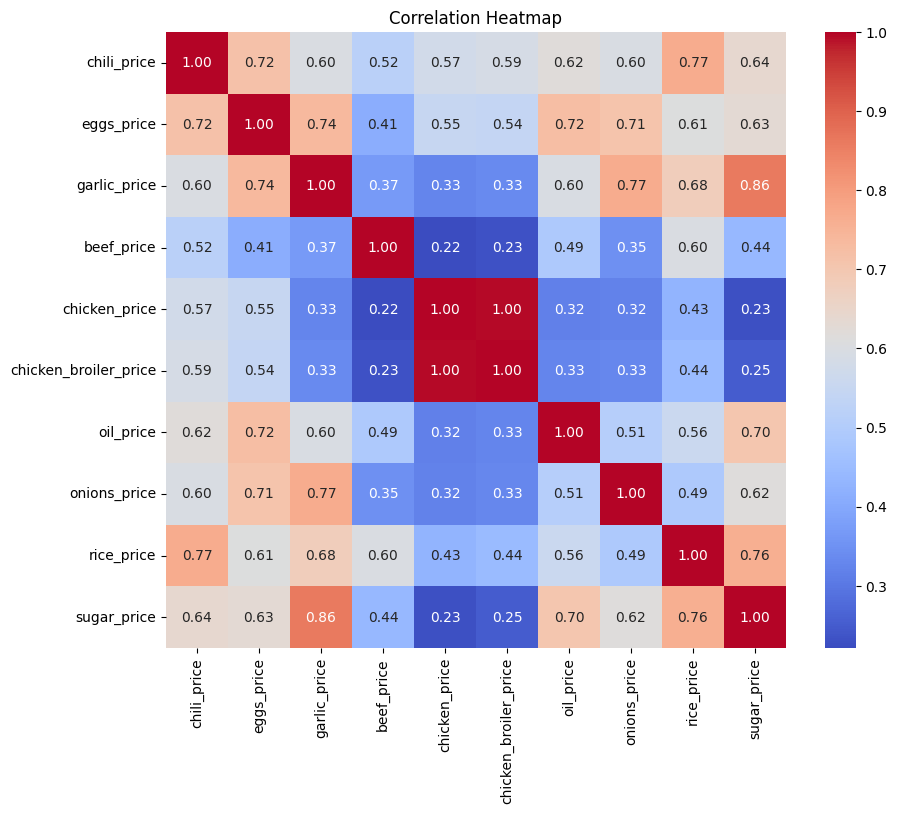

In [180]:
corr = food_clean.drop(columns=['province', 'year']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

<Axes: xlabel='fsi_score', ylabel='Count'>

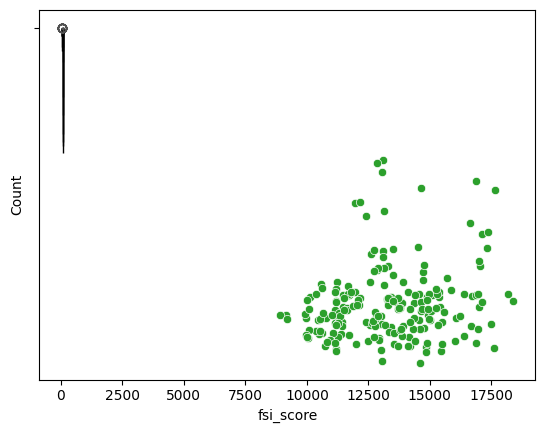

In [181]:
sns.histplot(df['fsi_score'])

sns.boxplot(x=df['fsi_score'])

sns.scatterplot(x=df['rice_price'], y=df['fsi_score'])

# **Splitting Dataset**

In [182]:
X = df.drop(columns=['fsi_score', 'fsi', 'province'])
y = df['fsi_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [183]:
X_train.dtypes

,0
year,int64
chili_price,float64
eggs_price,float64
garlic_price,float64
beef_price,float64
chicken_price,float64
chicken_broiler_price,float64
oil_price,float64
onions_price,float64
rice_price,float64


# **Feature Preprocessing (Scaling)**

In [184]:
from sklearn.preprocessing import StandardScaler

# Normalization (using StandardScaler)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [185]:
# Final Dataset Check
print(X_train.shape)
print(X_test.shape)
print(pd.DataFrame(X_train).isna().sum().sum())

(163, 13)
(41, 13)
0
